# Unwatermarked Control Evaluation

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

RESULTS_ROOT = Path("../../results/experiment1")

VARIANT     = "prefix_10_unwatermarked"
N_SAMPLES   = 1000
BATCH_SIZE  = 32

METRIC_COLORS = {
    "acc@1":       "#377eb8",  # blue
    "mrr":         "#4daf4a",  # green
    "normrank":    "#e41a1c",  # red
    "bm25_answer": "#984ea3",  # purple (BM25-PostGen, query = generated answer)
    "bm25_prompt": "#ff7f00",  # orange (BM25-PostRet, query = prompt)
}

# Font size for legends, axis labels and tick labels.
FONT_SIZE = 14

# Where the figure PDFs are written.
FIG_DIR = Path("../../thesis/figures/results/unwatermarked_control")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def _load_json(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def _bm25_acc1(d):
    """Acc@1 from a BM25 result dict (`bm25_*_original.json`), NaN if missing."""
    if d is None:
        return float("nan")
    ranks = np.asarray(d["correct_ranks"], dtype=np.float64)
    return float((ranks <= 1).mean()) if ranks.size else float("nan")


def collect_trajectory(variant=VARIANT, n_samples=N_SAMPLES, batch_size=BATCH_SIZE):
    """Per-epoch Acc@1, MRR, NormRank (WMCite) and the two BM25
    baseline Acc@1 values for the unwatermarked control."""
    base = RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
    eps, acc1, mrr, normrank, bm25_ans, bm25_prm = [], [], [], [], [], []
    for ep_dir in sorted(base.iterdir()):
        if not ep_dir.is_dir():
            continue
        try:
            ep = int(ep_dir.name)
        except ValueError:
            continue
        d = _load_json(ep_dir / "verification_closed.json")
        if d is None:
            continue
        ranks = np.asarray(d["correct_ranks"], dtype=np.float64)
        if ranks.size == 0:
            continue
        eps.append(ep)
        acc1.append(float((ranks <= 1).mean()))
        mrr.append(float((1.0 / ranks).mean()))
        normrank.append(float((ranks / d["n_candidates"]).mean()))
        bm25_ans.append(_bm25_acc1(_load_json(ep_dir / "bm25_answer_original.json")))
        bm25_prm.append(_bm25_acc1(_load_json(ep_dir / "bm25_prompt_original.json")))
    order = np.argsort(eps)
    return {
        "epoch":       np.asarray(eps, dtype=np.int64)[order],
        "acc@1":       np.asarray(acc1, dtype=np.float64)[order],
        "mrr":         np.asarray(mrr, dtype=np.float64)[order],
        "normrank":    np.asarray(normrank, dtype=np.float64)[order],
        "bm25_answer": np.asarray(bm25_ans, dtype=np.float64)[order],
        "bm25_prompt": np.asarray(bm25_prm, dtype=np.float64)[order],
    }


traj = collect_trajectory()
for ep, a, m, r, ba, bp in zip(traj["epoch"], traj["acc@1"], traj["mrr"],
                               traj["normrank"], traj["bm25_answer"],
                               traj["bm25_prompt"]):
    print(f"epoch={ep:>3d}  acc@1={a:.3f}  mrr={m:.3f}  normrank={r:.3f}  "
          f"bm25_postgen={ba:.3f}  bm25_postret={bp:.3f}")

epoch=  5  acc@1=0.002  mrr=0.009  normrank=0.516  bm25_postgen=0.423  bm25_postret=0.910
epoch= 10  acc@1=0.002  mrr=0.008  normrank=0.504  bm25_postgen=0.501  bm25_postret=0.910
epoch= 15  acc@1=0.002  mrr=0.008  normrank=0.493  bm25_postgen=0.698  bm25_postret=0.910
epoch= 20  acc@1=0.000  mrr=0.008  normrank=0.483  bm25_postgen=0.880  bm25_postret=0.910
epoch= 25  acc@1=0.000  mrr=0.007  normrank=0.498  bm25_postgen=0.950  bm25_postret=0.910
epoch= 30  acc@1=0.000  mrr=0.006  normrank=0.505  bm25_postgen=0.977  bm25_postret=0.910
epoch= 35  acc@1=0.000  mrr=0.006  normrank=0.505  bm25_postgen=0.986  bm25_postret=0.910
epoch= 40  acc@1=0.000  mrr=0.006  normrank=0.496  bm25_postgen=0.995  bm25_postret=0.910
epoch= 45  acc@1=0.003  mrr=0.008  normrank=0.498  bm25_postgen=0.998  bm25_postret=0.910
epoch= 50  acc@1=0.001  mrr=0.007  normrank=0.512  bm25_postgen=0.995  bm25_postret=0.910
epoch= 55  acc@1=0.001  mrr=0.006  normrank=0.501  bm25_postgen=0.998  bm25_postret=0.910
epoch= 60 

## Training Trajectory

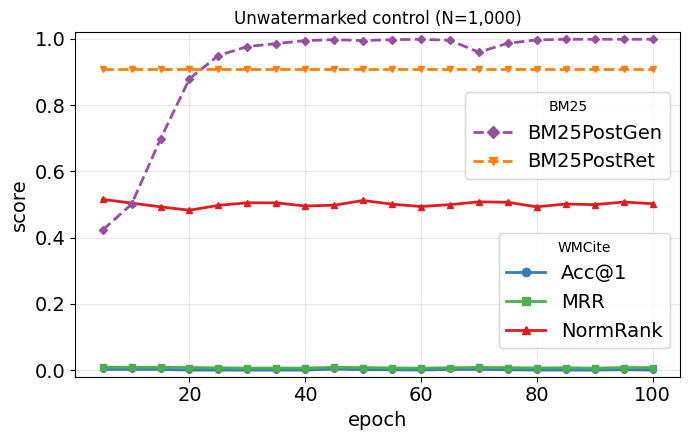

In [3]:
def plot_control(traj, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    xs = traj["epoch"]
    ax.plot(xs, traj["acc@1"], color=METRIC_COLORS["acc@1"], marker="o",
            ms=4, lw=2.0)
    ax.plot(xs, traj["mrr"], color=METRIC_COLORS["mrr"], marker="s",
            ms=4, lw=2.0)
    ax.plot(xs, traj["normrank"], color=METRIC_COLORS["normrank"], marker="^",
            ms=4, lw=2.0)
    ax.plot(xs, traj["bm25_answer"], color=METRIC_COLORS["bm25_answer"],
            marker="D", ms=4, lw=2.0, linestyle="--")
    ax.plot(xs, traj["bm25_prompt"], color=METRIC_COLORS["bm25_prompt"],
            marker="v", ms=4, lw=2.0, linestyle="--")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Unwatermarked control (N={N_SAMPLES:,})")
    ax.set_xlabel("epoch", fontsize=FONT_SIZE)
    ax.set_ylabel("score", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")

    bm25_handles = [
        Line2D([0], [0], color=METRIC_COLORS["bm25_answer"], marker="D",
               lw=2.0, linestyle="--", label="BM25PostGen"),
        Line2D([0], [0], color=METRIC_COLORS["bm25_prompt"], marker="v",
               lw=2.0, linestyle="--", label="BM25PostRet"),
    ]
    verifier_handles = [
        Line2D([0], [0], color=METRIC_COLORS["acc@1"], marker="o", lw=2.0,
               label="Acc@1"),
        Line2D([0], [0], color=METRIC_COLORS["mrr"], marker="s", lw=2.0,
               label="MRR"),
        Line2D([0], [0], color=METRIC_COLORS["normrank"], marker="^", lw=2.0,
               label="NormRank"),
    ]
    leg_bm25 = ax.legend(handles=bm25_handles, loc="center right",
                         bbox_to_anchor=(1.0, 0.70), fontsize=FONT_SIZE,
                         title="BM25")
    ax.add_artist(leg_bm25)
    ax.legend(handles=verifier_handles, loc="center right",
              bbox_to_anchor=(1.0, 0.25), fontsize=FONT_SIZE, title="WMCite")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_control(traj, save_path=FIG_DIR / "unwatermarked_control_metrics.pdf")

## Metrics at epoch 100

In [4]:
FINAL_EPOCH = 100
ep_i = int(np.where(traj["epoch"] == FINAL_EPOCH)[0][0])

TABLE_ROWS = [
    ("Acc@1",             "acc@1"),
    ("MRR",               "mrr"),
    ("NormRank",          "normrank"),
    ("BM25PostGen Acc@1", "bm25_answer"),
    ("BM25PostRet Acc@1", "bm25_prompt"),
]

lines = [
    r"\begin{table}[t]",
    r"  \centering",
    r"  \caption{Unwatermarked control metrics at the final epoch (epoch~100) "
    rf"for $N={N_SAMPLES:,}$.}}",
    r"  \label{tab:unwatermarked_control_metrics}",
    r"  \begin{tabular}{lr}",
    r"    \toprule",
    r"    Metric & Value \\",
    r"    \midrule",
]
for label, key in TABLE_ROWS:
    lines.append(f"    {label} & {traj[key][ep_i]:.3f} " + r"\\")
lines += [
    r"    \bottomrule",
    r"  \end{tabular}",
    r"\end{table}",
]
latex_table = "\n".join(lines)
print(f"epoch {FINAL_EPOCH}\n")
print(latex_table)

epoch 100

\begin{table}[t]
  \centering
  \caption{Unwatermarked control metrics at the final epoch (epoch~100) for $N=1,000$.}
  \label{tab:unwatermarked_control_metrics}
  \begin{tabular}{lr}
    \toprule
    Metric & Value \\
    \midrule
    Acc@1 & 0.000 \\
    MRR & 0.007 \\
    NormRank & 0.502 \\
    BM25PostGen Acc@1 & 0.999 \\
    BM25PostRet Acc@1 & 0.910 \\
    \bottomrule
  \end{tabular}
\end{table}


## Values at the first epoch

In [5]:
TARGET_EPOCH = 1
if TARGET_EPOCH in traj["epoch"]:
    ep_show = TARGET_EPOCH
else:
    ep_show = int(traj["epoch"].min())
    print(f"(epoch {TARGET_EPOCH} not evaluated; showing earliest epoch {ep_show})")
i = int(np.where(traj["epoch"] == ep_show)[0][0])

print(f"epoch {ep_show}:")
print(f"  Acc@1             = {traj['acc@1'][i]:.3f}")
print(f"  MRR               = {traj['mrr'][i]:.3f}")
print(f"  NormRank          = {traj['normrank'][i]:.3f}")
print(f"  BM25PostGen Acc@1 = {traj['bm25_answer'][i]:.3f}")
print(f"  BM25PostRet Acc@1 = {traj['bm25_prompt'][i]:.3f}")

(epoch 1 not evaluated; showing earliest epoch 5)
epoch 5:
  Acc@1             = 0.002
  MRR               = 0.009
  NormRank          = 0.516
  BM25PostGen Acc@1 = 0.423
  BM25PostRet Acc@1 = 0.910
